# SiliconGuard: Predictive Maintenance EDA & Validation
## Project Overview
This notebook demonstrates the end-to-end machine learning pipeline for predicting the **Remaining Useful Life (RUL)** of semiconductor manufacturing equipment.

In [1]:
import os
import sys
import pandas as pd
import warnings
warnings.filterwarnings('ignore')  #sometimes warnings are not cool lol


def find_project_root(search_path, identifier='src'):
    """Walk up the directory tree to find the project root containing 'src'."""
    current_dir = os.path.abspath(search_path)
    while current_dir != os.path.dirname(current_dir):
        if os.path.exists(os.path.join(current_dir, identifier)):
            return current_dir
        current_dir = os.path.dirname(current_dir)
    return None

# 1. Identify Project Root
root = find_project_root(os.getcwd())
if root:
    sys.path.append(root)
    print(f"Project Root Identified")
    print(f"Added to sys.path in sys.path")
else:
    print("Error: Could not find project root (missing 'src' folder).")

# 2. Import Modules
try:
    from src.features import engineer_features
    from src.roi_engine import ROIEngine
    print("Module imports successful!")
except ImportError as e:
    print(f"Import error: {e}")

print("Environment setup complete.")

Project Root Identified
Added to sys.path in sys.path
Module imports successful!
Environment setup complete.


## 1. Load and Inspect Data

In [4]:
import os
# Use absolute path derived from the identified root to be 100% safe
data_path = os.path.join(root, 'data', 'raw', 'sensor_data.csv') if 'root' in locals() and root else None

if data_path and os.path.exists(data_path):
    df = pd.read_csv(data_path, parse_dates=['timestamp'])
    print(f"Loaded {len(df)} samples.")
    display(df.head())
else:
    print(f"Error: Data not found at {data_path}")

Loaded 2880 samples.


,timestamp,temperature_C,RUL_hours
0,2024-01-01 00:00:00,148.857870,2555
1,2024-01-01 01:00:00,148.051991,2554
2,2024-01-01 02:00:00,152.378700,2553
3,2024-01-01 03:00:00,150.193613,2552
4,2024-01-01 04:00:00,149.224812,2551


## 2. Visualizing Sensor Degradation

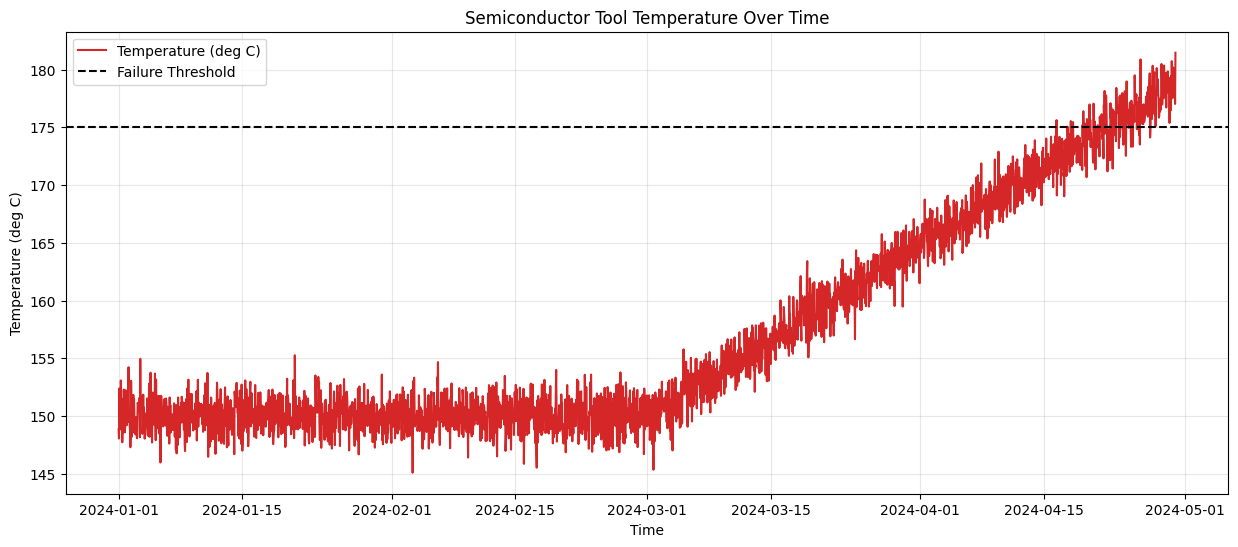

In [7]:
import matplotlib.pyplot as plt

if 'df' in locals():
    plt.figure(figsize=(15, 6))
    plt.plot(df['timestamp'], df['temperature_C'], label='Temperature (deg C)', color='tab:red')
    plt.axhline(y=175, color='black', linestyle='--', label='Failure Threshold')
    plt.title('Semiconductor Tool Temperature Over Time')
    plt.xlabel('Time')
    plt.ylabel('Temperature (deg C)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Error: DataFrame 'df' not found. Please run the loading cell first.")

## 3. Feature Engineering & Prediction

In [10]:
if 'df' in locals():
    processed_df = engineer_features(df)
    model_path = os.path.join(root, 'models', 'model.joblib') if 'root' in locals() else None
    import joblib
    if model_path and os.path.exists(model_path):
        payload = joblib.load(model_path)
        model = payload['model']
        feature_cols = payload['features']

        X = processed_df[feature_cols]
        predictions = model.predict(X)
        processed_df['predicted_RUL'] = predictions
        print("Prediction complete.")
    else:
        print(f"Error: Model not found at {model_path}")
else:
    print("Error: DataFrame 'df' not found. Please run the loading cell first.")

Prediction complete.


## 4. ROI Analysis

In [13]:
if 'processed_df' in locals():
    from src.roi_engine import ROIEngine
    roi_engine = ROIEngine()
    results = roi_engine.calculate_impact(processed_df)

    print("--- ROI Calculation Summary ---")
    for key, value in results.items():
        if 'percentage' in key:
            print(f"{key.replace('_', ' ').title()}: {value:.2f}%")
        else:
            print(f"{key.replace('_', ' ').title()}: ${value:,.2f}")
else:
    print("Error: processed_df not found. Please run the prediction cell first.")

--- ROI Calculation Summary ---
Reactive Total Cost: $16,250,000.00
Predictive Total Cost: $752,000.00
Net Savings: $15,498,000.00
Roi Percentage: 95.37%
